# Stellar Density Profiles and King Model Fitting

## Project Overview

This project analyzes the radial structure of a stellar cluster using Gaia DR3 catalogue data. The analysis combines astronomical data processing, statistical modelling, uncertainty estimation, and population-level comparisons to characterize the cluster's stellar-density profile.

The workflow covers four main stages:

1. Constructing the radial stellar-density profile from Gaia DR3 data.
2. Fitting a King model to the observed density profile.
3. Quantifying parameter uncertainties using chi-square grids and bootstrap resampling.
4. Comparing the cluster structure across stellar populations selected by G-band magnitude and proper motion.

### Tools and Methods

**Python · NumPy · Pandas · SciPy · Astropy · Matplotlib · lmfit · Gaia DR3**




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import pandas as pd
from astropy.io import fits
from lmfit import Model, Parameters , fit_report
import scipy.interpolate as spinterp
import scipy.integrate as spint
from lmfit.minimizer import Minimizer


In [2]:
# Load the data from the FITS file given. 
dr3stars = fits.open('gaiadr3_cluster_stars.fits')
dr3stars.info()
print(dr3stars[1].columns)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()

clcounts = stars.groupby(['Name']).size().reset_index(name='count')

Filename: gaiadr3_cluster_stars.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      93   ()      
  1  members.dat    1 TableHDU       331   1291929R x 56C   [A20, I4, I19, I1, F10.8, F12.8, F10.8, F12.8, F10.8, F12.8, E11.4, E11.4, F10.8, E11.4, F10.8, E11.4, F10.8, F11.8, F11.8, E11.4, E11.4, E11.4, E11.4, E11.4, E11.4, I2, F12.8, F10.7, F11.8, F10.8, F19.8, F16.8, F18.8, F17.8, F18.8, F17.8, F10.7, F10.7, F10.7, E11.4, E11.4, E11.4, E9.3, F12.8, F4.1, F6.1, F5.1, F11.7, F11.8, F6.1, F12.7, F13.8, F5.1, A13, I1, I1]   
ColDefs(
    name = 'Name'; format = 'A20'; start = 1
    name = 'ID'; format = 'I4'; disp = 'I4'; start = 22
    name = 'GaiaDR3'; format = 'I19'; disp = 'I19'; start = 27
    name = 'inrt'; format = 'I1'; disp = 'I1'; start = 47
    name = 'Prob'; format = 'F10.8'; disp = 'F10.8'; start = 49
    name = 'RAdeg'; format = 'F12.8'; unit = 'deg'; disp = 'F12.8'; start = 60
    name = 'e_RAdeg'; format = 'F10.8'; unit = 

# Stellar Density Profile of a Gaia DR3 Stellar Cluster

This analysis uses Gaia DR3 stellar data to characterize the radial structure of a stellar cluster. The workflow begins by selecting the target cluster and constructing its radial stellar-density profile from the sky coordinates of its member stars.

The cluster centre is estimated from the mean right ascension (RA) and declination (Dec). Radial distances are then calculated for the individual stars, and the stars are binned in radius to obtain the surface-density profile, including the corresponding uncertainties.

### Methodology

- Select the target stellar cluster from the Gaia DR3 catalogue.
- Estimate the cluster centre from the mean RA and Dec of its stars.
- Calculate the radial distance of each star from the estimated centre.
- Construct radial bins and calculate the stellar density in each bin, normalized by the bin area.
- Visualize the resulting radial density profile with uncertainties.

### Assumptions

- The centre of the cluster is approximated by the mean RA and Dec of the stars in the selected sample.
- The stellar distribution is treated as continuous within each radial bin.
- Each star contributes equally to the density estimate within its radial bin.

### Results

The resulting profile shows the expected increase in stellar density toward the central region of the cluster, where the radial distance is smallest. A logarithmic representation of the radial distance and density is also used to make the structure of the profile easier to examine.

The uncertainties are primarily associated with the finite number of stars contributing to each radial bin and become more pronounced toward the outer regions, where fewer stars are available.


In [3]:
def histrebin(mininbin,counts,edges):

    '''Takes as input a minimum counts per bin and a histogram counts and bin edges, and combines 
       adjacent histogram bins as needed so that no bin has less than the required minimum.
       Inputs:
           mininbin - required minimum counts/bin.
           counts, edges - input histogram counts/bin and bin edges arrays.
       Outputs:
           counts2, edges2 - rebinned counts/bin and bin edges arrays'''
    
    edges2=np.zeros(1)
    counts2=np.zeros(1)
    i=0
    countsum=0
    firstbin_flag = 1
    edges2[0]=edges[0]
    for x in counts:
        countsum=countsum+x
        i=i+1
        if countsum >= mininbin and (sum(counts[i:]) >= mininbin or i == len(counts)):  # The sum over counts in 
            # remaining bins ensures that we are not left with a bin with counts less than our limit at the end.
            if firstbin_flag == 1: # if this is the first bin satisfying our requirement, 
                # do not append but replace bin 0 with countsum
                counts2[0]=countsum
                firstbin_flag = 0 # now we read the first bin we can switch this off
            else:
                counts2=np.append(counts2,countsum)
            edges2=np.append(edges2,edges[i])
            countsum=0   
                 
    return counts2, edges2

def cluster_hist(cluster_data):
    # Define radial bins
    radial_bins = np.geomspace(cluster_data['Rad_Sep'].min(), cluster_data['Rad_Sep'].max(), num=60)

    # Create histogram for counts
    counts, edges = np.histogram(cluster_data['Rad_Sep'], bins=radial_bins)

    # Set minimum number of bins 
    mincounts = 20  
    counts2, edges2 = histrebin(mincounts, counts, edges)

    # Calculate areas of annuli
    area = np.pi * (edges2[1:] ** 2 - edges2[:-1] ** 2)

    # Stellar density
    density = counts2 / area

    # Calculate bin centers
    bin_centers = (edges2[:-1] + edges2[1:]) / 2

    # Calculate erros
    yerr = np.sqrt(counts2)/area

    xerr = (edges2[1:] - edges2[:-1]) / 2
    
    return density, edges2, bin_centers, yerr, xerr

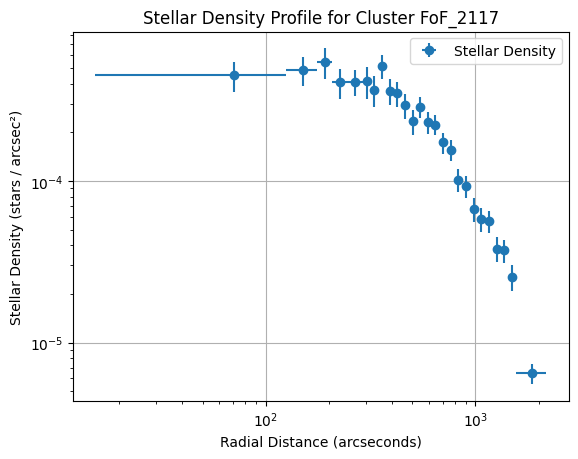

In [4]:
# Select given cluster 'FoF_2117'
cluster_data = stars[stars['Name'] == 'FoF_2117']

# Calculate the mean x = RA and y = DE
mean_RA = cluster_data['RAdeg'].mean()
mean_DE = cluster_data['DEdeg'].mean()
                       
# Calculate the Radial Seperation and assign a new column into the DataFrame 
cluster_data = cluster_data.assign(Rad_Sep = 3600 * np.sqrt((cluster_data.RAdeg - mean_RA)**2 + (cluster_data.DEdeg - mean_DE)**2))

density, edges2, bin_centers, yerr, xerr = cluster_hist(cluster_data)

# Plot stellar density profile
plt.errorbar(bin_centers, density, yerr , xerr, fmt='o', label='Stellar Density')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Radial Distance (arcseconds)')
plt.ylabel('Stellar Density (stars / arcsec²)')
plt.title('Stellar Density Profile for Cluster FoF_2117')
plt.grid(True)
plt.legend()
plt.show()



# King Model Fitting

The observed radial density profile is modelled using a King profile, an empirical model commonly used to describe the projected stellar-density structure of star clusters.

The model is integrated over the same radial bins used for the observations so that the predicted values can be compared directly with the binned stellar densities. The model parameters are then optimized using a least-squares approach.

### Model-fitting approach

The fit estimates the characteristic parameters of the density profile, including:

- **Central density (`rho0`)**
- **Core radius (`rc`)**
- **Tidal radius (`rt`)**

The `lmfit` package is used to perform the optimization and calculate the residuals. The final visualization combines the observed density profile, the best-fitting King model, and the residuals.

### Assumptions

- The King profile provides an appropriate parametric description of the observed stellar-density distribution.
- The uncertainties in the binned density measurements are suitable for a chi-square-based fitting procedure.
- The stellar counts are treated as Poisson-like measurements.
- A minimum of 20 counts per radial bin is used to support the approximation of the binned uncertainties.

### Results

The best-fitting model gives a minimum chi-square of **χ² = 15.22 for 23 degrees of freedom**, corresponding to a reduced chi-square of **χ²/dof = 0.662** and a goodness-of-fit p-value of **0.887**.

The fitted King profile follows the observed radial-density measurements closely. The residuals are examined as ratios between the observations and model predictions, making deviations easier to identify across the full density range. The points remain distributed around unity, with no obvious systematic deviation from the fitted model.


In [5]:

def model_bin(xbins, model, params):
    '''General function for integrating the input model over bins defined by contiguous (no gaps) 
        bin edges, xbins.
       Inputs:
           xbins - x bin edges.
           model, params - the model name and associated Parameters object.
       Outputs:
           ymod - calculated counts-density model values for y-axis.'''

    ymod = np.zeros(len(xbins)-1)

    for i, xval in enumerate(xbins[:-1]):
        
        # Integrate the king profile function over the area of a radial bin 
        ymod[i], ymoderr = spint.quad(lambda x: 2 * np.pi * x * model(x, params),xbins[i],xbins[i+1])

        # Divide by the bin area 
        ymod[i] = ymod[i]/(np.pi * (xbins[i+1]**2 - xbins[i]**2))
        
    return ymod


def lmf_lsq_binresid(params,xdata,ydata,yerrs,model,output_resid=True):
    '''lmfit objective function to calculate and return residual array or model y-values for
        binned data where the xdata are the input bin edges and ydata are the densities (integral over bin
        divided by bin width).
        Inputs: params - name of lmfit Parameters object set up for the fit.
                xdata, ydata, yerrs - lists of 1-D arrays of x (must be bin edges not bin centres) 
                and y data and y-errors to be fitted.
                    E.g. for 2 data sets to be fitted simultaneously:
                        xdata = [x1,x2], ydata = [y1,y2], yerrs = [err1,err2], where x1, y1, err1
                        and x2, y2, err2 are the 'data', sets of 1-d arrays of length n1 (n1+1 for x2
                        since it is bin edges), n2 (n2+1 for x2) respectively, 
                        where n1 does not need to equal n2.
                    Note that a single data set should also be given via a list, i.e. xdata = [x1],...
                model - the name of the model function to be used (must take params as its input params and
                        return the model y-value array for a given x-value array).
                output_resid - Boolean set to True if the lmfit objective function (residuals) is
                        required output, otherwise a list of model y-value arrays (corresponding to the 
                        input x-data list) is returned.
        Output: if output_resid==True, returns a residual array of (y_i-y_model(x_i))/yerr_i which is
            concatenated into a single array for all input data errors (i.e. length is n1+n2 in 
            the example above). If output_resid==False, returns a list of y-model arrays (one per input x-array)'''
    if output_resid == True:
        for i, xvals in enumerate(xdata):  # loop through each input dataset and record residual array
            if i == 0:
                resid = (ydata[i]-model_bin(xdata[i],model,params))/yerrs[i]
            else:
                resid = np.append(resid,(ydata[i]-model_bin(xdata[i],model,params))/yerrs[i])
        return resid
    else:
        ymodel = []
        for i, xvals in enumerate(xdata): # record list of model y-value arrays, one per input dataset
            ymodel.append(model_bin(xdata[i],model,params))
        return ymodel
    
def King_profile(r, params):
    """
    Computes the stellar density based on the King profile model.

    The King profile is used to model the radial distribution of stellar density in star clusters. 
    It incorporates a core radius (rc), tidal radius (rt), and central density (rho0), along with a constant background density (c).

    Inputs:
    r : array-like
        Radial distances at which to evaluate the stellar density.
    params : dict-like
        A dictionary containing the model parameters:
        'rho0': Central stellar density
        'rc': Core radius
        'rt': Tidal radius
        'c': Constant background density

    Outout:
    array-like
        The computed stellar density at each radial distance r. For radii larger than the tidal radius rt, 
        the density is constant at the value of c. For radii smaller than rt, the density is computed using the King profile formula.

    """
    # Extract numerical values from params
    rho0 = params['rho0']
    rc = params['rc']
    rt = params['rt']
    c = params['c']

    return np.where(r <= rt, rho0 * ((1 / np.sqrt(1 + (r / rc)**2)) - (1 / np.sqrt(1 + (rt / rc)**2)))**2 + c, c)
    

def goodness_fit(model, edges, density, yerr, params):              
    """
    Fits a given model to the provided data using the least-squares method, evaluates the goodness of fit, 
    and prints the optimized parameters with their uncertainties.

    Inputs:
    model : 
        The model function to fit.
    edges : array-like
        The bin edges for the radial distance data.
    density : array-like
        The observed stellar density values corresponding to the bin edges.
    yerr : array-like
        The errors associated with the density values.
    params : Parameters()
        The initial guesses and bounds for the model parameters. 
       

    Output:
    None
        This function prints the results of the fit, the minimum chi-squared value,
        degrees of freedom, the goodness-of-fit value,
        and the optimized parameter values and their uncertainties
    
    """
    output_resid = True
    xdata = [edges]
    ydata = [density]
    yerrs = [yerr]
    set_function = Minimizer(lmf_lsq_binresid, params, fcn_args=(xdata, ydata, yerrs, model, output_resid),nan_policy='omit')
    result = set_function.minimize(method = 'leastsq')

    print("Minimum Chi-squared = "+str(result.chisqr)+" for "+str(result.nfree)+" d.o.f.")
    print("The goodness of fit is: ",sps.chi2.sf(result.chisqr,df=result.nfree))

    # Print the fitted parameters
    for param_name, param in result.params.items():
        print(f"{param_name}: {param.value:.6f} ± {param.stderr if param.stderr is not None else 'N/A'}")
    return result, xdata, ydata, yerrs

def plot_spec_model(ebins,cdens,cdens_err,cdens_model):
    '''Plot the binned Stellar Density with the model as a histogram, and 
       data/model residuals.
       Inputs:
           ebins - energy bin edges.
           cdens, cdens_err - counts density and its error.
           cdens_model - model counts density.'''
    energies = (ebins[1:]+ebins[:-1])/2
    bwidths = np.diff(ebins)
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6),sharex=True,gridspec_kw={'height_ratios':[2,1]})
    fig.subplots_adjust(hspace=0)
    ax1.errorbar(energies, cdens, xerr=bwidths/2., yerr=cdens_err, fmt='o')
    model_hist, edges, patches = ax1.hist(energies, bins=ebins, weights=cdens_model, 
                                      density=False, histtype='step')
    ax2.errorbar(energies, cdens/cdens_model, xerr=bwidths/2., yerr=cdens_err/cdens_model, fmt='o')
    ax2.set_xlabel('Radial Distance (arcseconds)', fontsize=16)
    ax1.set_ylabel('Stellar Density (stars / arcsec²)', fontsize=14)
    ax2.set_ylabel("data/model", fontsize=14)
    ax2.axhline(1.0, color='r', linestyle='dotted', lw=2) 
    ax1.tick_params(labelsize=14)
    ax1.tick_params(axis="x",direction="in",which="both", length=4)
    ax2.tick_params(axis="x",which="both", length=4)
    ax2.tick_params(labelsize=14)
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax1.get_yaxis().set_label_coords(-0.12,0.5)
    ax2.get_yaxis().set_label_coords(-0.12,0.5)
    ax2.set_xlim(ebins[0],ebins[-1]) 
    plt.show()



In [6]:
params=Parameters()
params.add('rho0', value=0.01, min=0, max=0.1)
params.add('rc', value=150, min=0, max=1000)
params.add('rt', value=2000, min=0, max=5000)
params.add('c', value=0, vary=False)

result, xdata, ydata, yerrs = goodness_fit(King_profile, edges2, density, yerr, params)
print(fit_report(result))

Minimum Chi-squared = 15.220460590080902 for 23 d.o.f.
The goodness of fit is:  0.8865583599811485
rho0: 0.000914 ± 4.1784808832095374e-05
rc: 612.820468 ± 42.008307864630645
rt: 2595.820796 ± 105.27955545316868
c: 0.000000 ± 0
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 43
    # data points      = 26
    # variables        = 3
    chi-square         = 15.2204606
    reduced chi-square = 0.66175916
    Akaike info crit   = -7.92185402
    Bayesian info crit = -4.14756441
[[Variables]]
    rho0:  9.1410e-04 +/- 4.1785e-05 (4.57%) (init = 0.01)
    rc:    612.820468 +/- 42.0083079 (6.85%) (init = 150)
    rt:    2595.82080 +/- 105.279555 (4.06%) (init = 2000)
    c:     0 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(rc, rt)   = -0.7432
    C(rho0, rt) = -0.5157


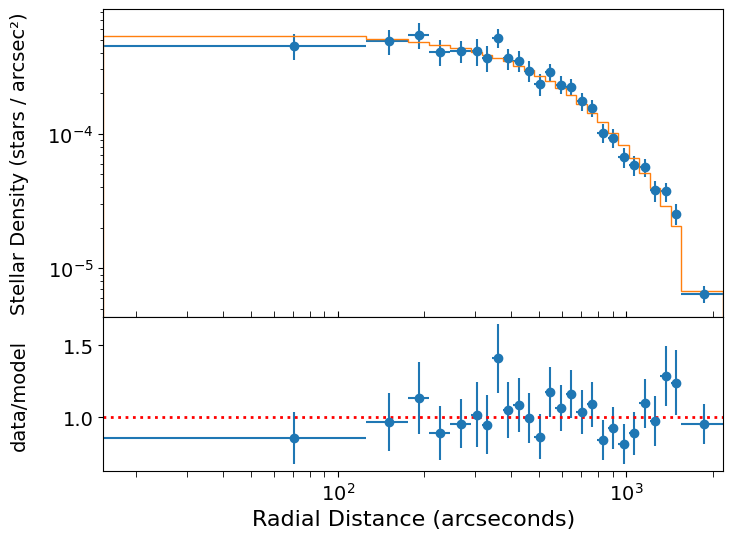

In [7]:

# Calculate the best-fitting model values, with the parameters of the best fit output
model_vals = lmf_lsq_binresid(result.params,xdata,ydata,yerrs,King_profile,output_resid=False)

# Plot the data and model and residuals
plot_spec_model(edges2,density,yerr,model_vals[0])


# Parameter Uncertainty and Model Robustness

After obtaining the best-fitting King model, the next step is to quantify the uncertainty of its parameters and assess the robustness of the fit.

Two complementary approaches are used:

1. **Grid-based chi-square analysis** to identify parameter intervals corresponding to approximately 1-sigma and 3-sigma confidence levels.
2. **Bootstrap resampling** to estimate the distribution and uncertainty of the fitted parameters from repeated fits to resampled data.

The parameters investigated are the central density (`rho0`), core radius (`rc`), and tidal radius (`rt`).

### Confidence-interval analysis

A grid of parameter values is explored while optimizing the remaining free parameters. The resulting chi-square curves are used to identify the regions corresponding to Δχ² = 1 and Δχ² = 9, representing the 1-sigma and 3-sigma intervals used in this analysis.

The corresponding chi-square profiles are plotted for each model parameter, allowing the width and shape of the uncertainty regions to be inspected directly.

### Bootstrap analysis

The dataset is resampled and the King model is fitted repeatedly, using 500 bootstrap realizations. The resulting parameter distributions provide an independent estimate of the uncertainty around the maximum-likelihood estimates.

### Assumptions

- The radial-density measurements are treated as independent for the chi-square analysis.
- The measurement uncertainties are approximated as Gaussian.
- The fitted parameter estimates are assumed to be sufficiently well behaved for the bootstrap distributions to provide useful uncertainty estimates.

### Results

The chi-square profiles provide a visual assessment of how sensitive the fit is to changes in each model parameter. The 1-sigma intervals are not closed for all parameters, so the broader 3-sigma intervals are also examined.

The bootstrap estimates give uncertainty ranges around the best-fitting parameter values that are broadly consistent with the grid-based analysis, providing an additional check on the robustness of the fitted King model.


In [8]:
def grid1d_chisqmin(a_name,a_range,a_steps,parm,model,xdata,ydata,yerrs):
    '''Uses lmfit. Finds best the fit and then carries out chisq minimisation for a 1D grid of fixed 
       parameters.
        Inputs: 
            a_name - string, name of 'a' parameter (in input Parameters object parm) to use for grid.
            a_range, a_steps - range (tuple or list) and number of steps for grid.
            parm - lmfit Parameters object for model to be fitted.
            model - name of model function to be fitted.
            xdata, ydata, yerrs - lists of data x, y and y-error arrays (as for the lmf_lsq_resid function)
        Output: 
            a_best - best-fitting value for 'a'
            minchisq - minimum chi-squared (for a_best)
            a_grid - grid of 'a' values used to obtain fits
            chisq_grid - grid of chi-squared values corresponding to a_grid'''
    a_grid = np.linspace(a_range[0],a_range[1],a_steps)
    chisq_grid = np.zeros(len(a_grid))
    # First obtain best-fitting value for 'a' and corresponding chi-squared
    set_function = Minimizer(lmf_lsq_binresid, parm, fcn_args=(xdata, ydata, yerrs, model, True),
                             nan_policy='omit')
    result = set_function.minimize(method = 'leastsq')
    minchisq = result.chisqr
    a_best = result.params.valuesdict()[a_name]
    # Now fit for each 'a' in the grid, to do so we use the .add() method for the Parameters object
    # to replace the value of a_name with the value for the grid, setting vary=False to freeze it
    # so it cannot vary in the fit (only the other parameters will be left to vary)
    for i, a_val in enumerate(a_grid):
        parm.add(a_name,value=a_val,vary=False)
        set_function = Minimizer(lmf_lsq_binresid, parm, fcn_args=(xdata, ydata, yerrs, model, True), 
                                                                nan_policy='omit')
        result = set_function.minimize(method = 'leastsq')
        chisq_grid[i] = result.chisqr
    return a_best, minchisq, a_grid, chisq_grid 

def interval_finder(delstat, a_best, min_fitstat, a_grid, fitstat_grid):
    """
    Finds the confidence interval bounds for a given parameter based on the fit statistic grid and delta statistic.

    Inputs:
    delstat : float
        The target change in the fit statistic corresponding to the desired confidence level.
    a_best : float
        The best-fit value of the parameter of interest.
    min_fitstat : float
        The minimum value of the fit statistic.
    a_grid : array-like
        The grid of parameter values over which the fit statistic has been evaluated.
    fitstat_grid : array-like
        The grid of fit statistic values corresponding to the parameter values in `a_grid`.

    Output:
    float
        lower and upper bounds of the confidence interval for the parameter of interest.

    """
    # Make sure that the parameter and fit-statistic grids are sorted.
    sortind = np.argsort(a_grid)
    a_grid = a_grid[sortind]
    fitstat_grid = fitstat_grid[sortind]
    ## Make an interpolate object with the chisq grid - best fit - delstat and find roots.
    a_interpsig = spinterp.CubicSpline(a_grid,np.array(fitstat_grid-min_fitstat-delstat))
    bounds = a_interpsig.roots()    
    #print('bounds',bounds,'fitstat a_min, a_max:',fitstat_grid[0]-min_fitstat,fitstat_grid[-1]-min_fitstat)
    ## Choose roots closest to best fitting value, as roots sometimes also returns values at the edges of the grid.
    return (bounds[bounds<a_best][-1],bounds[bounds>a_best][0])


Parameter ranges for grid: [[0.0007469592599348233, 0.0010812377305915862], [444.7872364956264, 780.8536994126715], [2174.702573885881, 3016.9390175112303]]


/var/folders/sz/99bw23pn1kd703lbn9t5v2740000gn/T/ipykernel_3100/644461033.py:15: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ymod[i], ymoderr = spint.quad(lambda x: 2 * np.pi * x * model(x, params),xbins[i],xbins[i+1])


MLE rho0: 0.0009 with errors: [-0.0001  0.0001]
MLE rc: 612.8205 with errors: [-47.4099  52.7949]
MLE rt: 2595.8208 with errors: [-118.6812  135.1011]
MLE rho0: 0.0009 with errors (3-sigma): [-0.0001  0.0002]
MLE rc: 612.8205 with errors (3-sigma): [-129.607   179.9621]
MLE rt: 2595.8208 with errors (3-sigma): [-322.0816  476.4519]


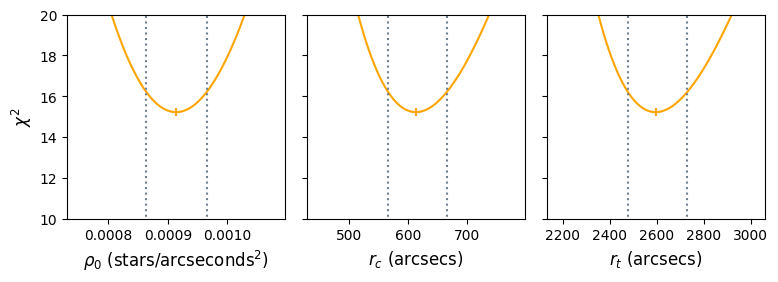

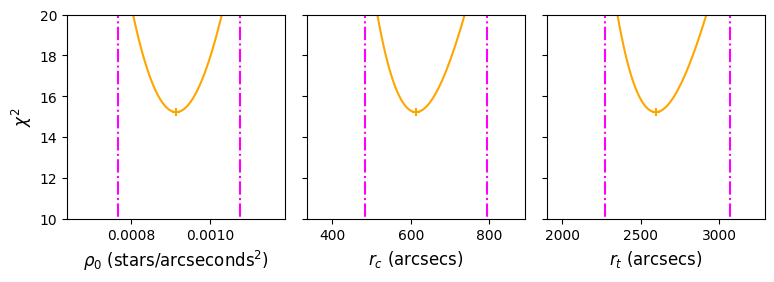

In [ ]:

model = King_profile
par_names = ['rho0','rc','rt'] # Names of parameters in Parameters object
n_steps = 100  # Number of steps in our grids
# Ranges for each parameter - should aim for a few times times 1-sigma error estimated from covariance
# We can specify by hand or use the values from the original minimize result if available:
par_ranges = []
par_ranges3 = []

for i, par_name in enumerate(par_names):

    par_min = result.params.valuesdict()[par_name] - 4*np.sqrt(result.covar[i,i])
    par_max = result.params.valuesdict()[par_name] + 4*np.sqrt(result.covar[i,i])
    par_ranges.append([par_min,par_max])

for i, par_name in enumerate(par_names):

    par_min3 = result.params.valuesdict()[par_name] - 6*np.sqrt(result.covar[i,i])
    par_max3 = result.params.valuesdict()[par_name] + 6*np.sqrt(result.covar[i,i])
    par_ranges3.append([par_min3,par_max3])   

print("Parameter ranges for grid:",par_ranges)
# For convenience when plotting we will store our results in arrays, which we now set up:
a_best = np.zeros(len(par_ranges))
minchisq = np.zeros(len(par_ranges))
a_grid = np.zeros((len(par_ranges),n_steps))
chisq_grid = np.zeros((len(par_ranges),n_steps))
a_int = np.zeros((len(par_ranges),2))

# 3 sigma
a_best3 = np.zeros(len(par_ranges3))
minchisq3 = np.zeros(len(par_ranges3))
a_grid3 = np.zeros((len(par_ranges3),n_steps))
chisq_grid3 = np.zeros((len(par_ranges3),n_steps))
a_int3 = np.zeros((len(par_ranges3),2))

delchisq = 1.0  # For 1-sigma errors for a single parameter 
delchisq3 = 9 # For 3-sigma errors for a single parameter

# Now do the grid calculation for each parameter:
for i, par_range in enumerate(par_ranges):
    params = Parameters()
    params.add('rho0', value=0.01, min=0, max=0.1)
    params.add('rc', value=150, min=0, max=1000)
    params.add('rt', value=2000, min=0, max=5000)
    params.add('c', value=0, vary=False)
    a_best[i], minchisq[i], a_grid[i,:], chisq_grid[i,:] = grid1d_chisqmin(par_names[i],par_range,n_steps,params,model,
                                 xdata,ydata,yerrs)
    a_int[i,:] = interval_finder(delchisq,a_best[i],minchisq[i],a_grid[i,:],chisq_grid[i,:])
    print('MLE '+par_names[i]+':',str(np.round(a_best[i],4)),
        'with errors:',str(np.round((a_int[i,:]-a_best[i]),4)))

for i, par_range3 in enumerate(par_ranges3):
    params = Parameters()
    params.add('rho0', value=0.01, min=0, max=0.1)
    params.add('rc', value=150, min=0, max=1000)
    params.add('rt', value=2000, min=0, max=5000)
    params.add('c', value=0, vary=False)
    a_best3[i], minchisq3[i], a_grid3[i,:], chisq_grid3[i,:] = grid1d_chisqmin(par_names[i],par_range3,n_steps,params,model,
                                 xdata,ydata,yerrs)
    a_int3[i,:] = interval_finder(delchisq3,a_best3[i],minchisq3[i],a_grid3[i,:],chisq_grid3[i,:])
    print('MLE '+par_names[i]+':',str(np.round(a_best3[i],4)),
        'with errors (3-sigma):',str(np.round((a_int3[i,:]-a_best3[i]),4)))

# Now plot along with a cross to mark the MLE and dotted lines to show the 1-sigma intervals
par_xlabels = [r'$\rho_{0}$ (stars/arcseconds$^2$)',r'$r_{c}$ (arcsecs)',r'$r_{t}$ (arcsecs)']


fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(9,3), sharey=True)
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=0.1, hspace=None)
for i, ax in enumerate([ax1, ax2, ax3]):
    ax.plot(a_grid[i,:],chisq_grid[i,:],color='orange')
    ax.scatter(a_best[i],minchisq[i],marker='+',color='orange')
    ax.vlines(a_int[i,:],ymin=0,ymax=30,color='slategray',linestyle='dotted', label='1-Sigma')
    ax.set_xlabel(par_xlabels[i],fontsize=12)
    ax.set_ylim(10,20)
ax1.set_ylabel(r'$\chi^{2}$',fontsize=12)
    
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(9,3), sharey=True)
fig.subplots_adjust(left=None, bottom=0.2, right=None, top=None, wspace=0.1, hspace=None)
for i, ax in enumerate([ax1, ax2, ax3]):
    ax.plot(a_grid3[i,:],chisq_grid3[i,:],color='orange')
    ax.scatter(a_best3[i],minchisq3[i],marker='+',color='orange')
    ax.vlines(a_int3[i,:],ymin=0,ymax=30,color='fuchsia',linestyle='-.', label='3-Sigma')    
    ax.set_xlabel(par_xlabels[i],fontsize=12)
    ax.set_ylim(10,20)
ax1.set_ylabel(r'$\chi^{2}$',fontsize=12)
    
plt.show()
 



In [10]:
#broostrapping
params=Parameters()
params.add('rho0', value=0.01, min=0, max=0.1)
params.add('rc', value=150, min=0, max=1000)
params.add('rt', value=2000, min=0, max=5000)
params.add('c', value=0, vary=False)
model = King_profile
nsims = 500
par_names = ['rho0','rt','rc']
params_p = []

for i in range(nsims):
    resampled_data = cluster_data['Rad_Sep'].sample(len(cluster_data), replace=True)
    # Define radial bins
    radial_bins = np.geomspace(resampled_data.min(), resampled_data.max(), num=60)

    # Create histogram for counts
    counts, edges = np.histogram(resampled_data, bins=radial_bins)

    # Set minimum number of bins 
    mincounts = 20  
    counts2, edges2 = histrebin(mincounts, counts, edges)

    # Calculate areas of annuli
    area = np.pi * (edges2[1:] ** 2 - edges2[:-1] ** 2)

    # Stellar density
    density = counts2 / area

    # Calculate bin centers
    bin_centers = (edges2[:-1] + edges2[1:]) / 2

    # Calculate erros
    yerr = np.sqrt(counts2)/area

    xerr = (edges2[1:] - edges2[:-1]) / 2

    output_resid = True
    xdata = [edges2]
    ydata = [density]
    yerrs = [yerr]
    set_function = Minimizer(lmf_lsq_binresid, params, fcn_args=(xdata, ydata, yerrs, model, output_resid),nan_policy='omit')
    result = set_function.minimize(method = 'leastsq')

    params_p.append([result.params[p].value for p in result.params if p != 'c'])

    
params_new = pd.DataFrame(params_p, columns=[p for p in result.params if p != 'c'])

print("---------------Bootstrapping - confidence intervals-------------------")
for i in range(3):
    print(f"{par_names[i]}: ({params_new[par_names[i]].mean()-params_new[par_names[i]].std()}, {params_new[par_names[i]].mean()+params_new[par_names[i]].std()})")
    


/var/folders/sz/99bw23pn1kd703lbn9t5v2740000gn/T/ipykernel_3100/644461033.py:15: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ymod[i], ymoderr = spint.quad(lambda x: 2 * np.pi * x * model(x, params),xbins[i],xbins[i+1])


---------------Bootstrapping - confidence intervals-------------------
rho0: (0.0008646854380497211, 0.0009419599252982454)
rt: (2447.9785504623505, 2683.4823951842272)
rc: (570.5615060850466, 679.5571994757604)


# Stellar Populations Across Magnitude and Proper-Motion Subsamples

The final stage of the analysis investigates whether the radial structure of the cluster changes across different stellar subpopulations.

Two stellar properties are considered:

- **G-band magnitude (`Gmag`)**
- **Absolute proper motion (`Abs_PM`)**

The cluster is divided into low- and high-value subsamples using the median of each property. Radial density profiles are then constructed separately for each subsample and compared with the profile of the full cluster population.

Each profile is fitted with the King model under three configurations:

1. Both `rc` and `rt` fixed.
2. `rc` fixed and `rt` allowed to vary.
3. `rt` fixed and `rc` allowed to vary.

This provides a way to investigate whether the characteristic spatial scales of the cluster depend on stellar magnitude or proper motion.

### Analysis assumptions

- The stellar density distribution is described by the King profile.
- The uncertainties in the radial-density measurements are treated as approximately Gaussian.
- The residuals are treated as statistically independent.
- The subsamples can be compared using the same underlying structural model.

### Results: G-band magnitude

For the G-band magnitude subsamples, the reported goodness-of-fit values are:

| Model configuration | Goodness of fit |
|---|---:|
| Fixed `rc` and `rt` | 0.691 |
| Fixed `rc`, free `rt` | 0.876 |
| Fixed `rt`, free `rc` | 0.964 |

When `rt` is allowed to vary, its fitted values remain similar between the subsamples. When `rc` is allowed to vary, differences between the subsamples are more apparent.

### Results: Proper motion

For the proper-motion subsamples, the reported goodness-of-fit values are:

| Model configuration | Goodness of fit |
|---|---:|
| Fixed `rc` and `rt` | 0.790 |
| Fixed `rc`, free `rt` | 0.798 |
| Fixed `rt`, free `rc` | 0.798 |

The fitted models remain broadly consistent across the proper-motion subsamples, with no strong indication from these goodness-of-fit values that the structural parameters vary substantially between the groups.

### Interpretation

Overall, the analysis provides a comparison of the cluster's radial structure across different stellar populations. The results are broadly consistent with a well-mixed population, while the variation in the fitted core radius across G-band magnitude subsamples provides a feature worth examining further.


In [ ]:
def model_bin_mult(xbins, model, i_data, params):
    '''General function for integrating the input model over bins defined by contiguous (no gaps) 
        bin edges, xbins.
       Inputs:
           xbins - x bin edges.
           i_data - the dataset being considered (determines which parameters to use in the model)
           model, params - the model name and associated Parameters object.
       Outputs:
           ymod - calculated counts-density model values for y-axis.'''

    ymod = np.zeros(len(xbins)-1)
    for i, xval in enumerate(xbins[:-1]):
        ymod[i], ymoderr = spint.quad(lambda x: 2 * np.pi * x * model(x, i_data, params), xbins[i], xbins[i + 1])
        ymod[i] = ymod[i]/(np.pi*(xbins[i + 1]**2-xbins[i]**2))  
    
    return ymod

def lmf_lsq_binresid_mult(params,xdata,ydata,yerrs,model,output_resid=True):
    '''lmfit objective function to calculate and return residual array or model y-values for
        binned data where the xdata are the input bin edges and ydata are the densities (integral over bin
        divided by bin width).
        Inputs: params - name of lmfit Parameters object set up for the fit.
                xdata, ydata, yerrs - lists of 1-D arrays of x (must be bin edges not bin centres) 
                and y data and y-errors to be fitted.
                    E.g. for 2 data sets to be fitted simultaneously:
                        xdata = [x1,x2], ydata = [y1,y2], yerrs = [err1,err2], where x1, y1, err1
                        and x2, y2, err2 are the 'data', sets of 1-d arrays of length n1 (n1+1 for x2
                        since it is bin edges), n2 (n2+1 for x2) respectively, 
                        where n1 does not need to equal n2.
                    Note that a single data set should also be given via a list, i.e. xdata = [x1],...
                model - the name of the model function to be used (must take params as its input params and
                        return the model y-value array for a given x-value array).
                output_resid - Boolean set to True if the lmfit objective function (residuals) is
                        required output, otherwise a list of model y-value arrays (corresponding to the 
                        input x-data list) is returned.
        Output: if output_resid==True, returns a residual array of (y_i-y_model(x_i))/yerr_i which is
            concatenated into a single array for all input data errors (i.e. length is n1+n2 in 
            the example above). If output_resid==False, returns a list of y-model arrays (one per input x-array)'''
    if output_resid == True:
        for i, xvals in enumerate(xdata):  # loop through each input dataset and record residual array
                     # Note that we identify the dataset by counting from 1 not 0, this is just the 
                    # standard we will use for naming the parameters.
            if i == 0:
                resid = (ydata[i]-model_bin_mult(xdata[i],model,i+1,params))/yerrs[i]
            else:
                resid = np.append(resid,(ydata[i]-model_bin_mult(xdata[i],model,i+1,params))/yerrs[i])
        return resid
    else:
        ymodel = []
        for i, xvals in enumerate(xdata): # record list of model y-value arrays, one per input dataset
            ymodel.append(model_bin_mult(xdata[i],model,i+1,params))
        return ymodel
    
def plot_spec_model_mult(ebins_list,cdens_list,cdens_err_list,cdens_model_list,resid_type,
                         legend_labels):
    '''Plot the binned (GeV) spectrum with the model as a histogram, and 
       data/model residuals.
       Inputs:
           ebins_list - energy bin edges.
           cdens_list, cdens_err_list - counts density and its error.
           cdens_model_list - model counts density.
           emin, emax - minimum and maximum energy to be plotted
           resid_type - string, type of data vs model residuals, these can be: 
               ratio: data/model, resid: data-model, weighted resid: data-model/error
           legend_labels - list of labels for each dataset to use in legend, 
                   use None if no legend required'''
    
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6),sharex=True,gridspec_kw={'height_ratios':[2,1]})
    fig.subplots_adjust(hspace=0)
    for i,ebins in enumerate(ebins_list):
        energies = (ebins[1:]+ebins[:-1])/2
        bwidths = np.diff(ebins)
        if legend_labels != None:
            label_txt = legend_labels[i]
        # Note that colours in the default Matplotlib colour cycle can be specified using strings 
        # 'C0'..'C9', which is useful for plotting the same colours for model and data.
        ax1.errorbar(energies, cdens_list[i], xerr=bwidths/2., yerr=cdens_err_list[i], 
                     color='C'+str(i), markersize=4, fmt='o', label=label_txt)
        model_hist, edges, patches = ax1.hist(energies, bins=ebins, weights=cdens_model_list[i], 
                    density=False, histtype='step', color='C'+str(i), alpha=0.5, 
                                              linestyle='dotted', linewidth=2)
        if resid_type == 'ratio':
            ax2.errorbar(energies, cdens_list[i]/cdens_model_list[i], xerr=bwidths/2., 
                    yerr=cdens_err_list[i]/cdens_model_list[i], color='C'+str(i), markersize=4, fmt='o')
        elif resid_type == 'resid':
            ax2.errorbar(energies, (cdens_list[i]-cdens_model_list[i]), xerr=bwidths/2., 
                    yerr=cdens_err_list[i], color='C'+str(i), markersize=4, fmt='o')
        elif resid_type == 'weighted resid':
            ax2.errorbar(energies, (cdens_list[i]-cdens_model_list[i])/cdens_err_list[i], xerr=bwidths/2., 
                    yerr=1.0, color='C'+str(i), markersize=4, fmt='o')
    ax2.set_xlabel("Radial distance (arcsec)", fontsize=14)
    ax1.set_ylabel(r'Stellar Density (stars/arcsec$^2$)', fontsize=14)
    ax1.get_yaxis().set_label_coords(-0.12,0.5)
    ax2.get_yaxis().set_label_coords(-0.12,0.5)
    if resid_type == 'ratio':
        ax2.set_ylabel("data/model", fontsize=14)
        ax2.axhline(1., color='gray', linestyle='dotted', lw=2)
    elif resid_type == 'resid':
        ax2.set_ylabel("data-model", fontsize=14)
        ax2.axhline(0., color='gray', linestyle='dotted', lw=2)
    elif resid_type == 'weighted resid':
        ax2.get_yaxis().set_label_coords(-0.09,0.5)
        ax2.set_ylabel(r"$\frac{data-model}{error}$", fontsize=16)
        ax2.axhline(0., color='gray', linestyle='dotted', lw=2)
    ax1.tick_params(labelsize=14)
    ax1.tick_params(axis="x",direction="in",which="both", length=4)
    ax2.tick_params(axis="x",which="both", length=4)
    ax2.tick_params(labelsize=14)
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax2.set_xscale('log')

    # Strictly speaking we should only show the energy range 
    # where data is sampled, to avoid impression from model that the flux suddenly drops 
    # at the boundaries.
    ax1.legend(fontsize=14)
    plt.show()

def King_profile_mult(r, i_data, params):
    """
    Computes the stellar density based on the King profile model for multiple data.

    The King profile is used to model the radial distribution of stellar density in star clusters. 
    It incorporates a core radius (rc), tidal radius (rt), and central density (rho0), along with a constant background density (c).

    Inputs:
    r : array-like
        Radial distances at which to evaluate the stellar density.
    params : dict-like
        A dictionary containing the model parameters:
        'rho0': Central stellar density
        'rc': Core radius
        'rt': Tidal radius
        'c': Constant background density
    i_data: int
        Dataset given 

    Outout:
    array-like
        The computed stellar density at each radial distance r. For radii larger than the tidal radius rt, 
        the density is constant at the value of c. For radii smaller than rt, the density is computed using the King profile formula.

    """
    # Extract numerical values from params
    rho0 = params['rho0' + str(i_data)]
    rc = params['rc' + str(i_data)]
    rt = params['rt' + str(i_data)]
    c = params['c' + str(i_data)]

    return np.where(r <= rt, rho0 * ((1 / np.sqrt(1 + (r / rc)**2)) - (1 / np.sqrt(1 + (rt / rc)**2)))**2 + c, c)
    


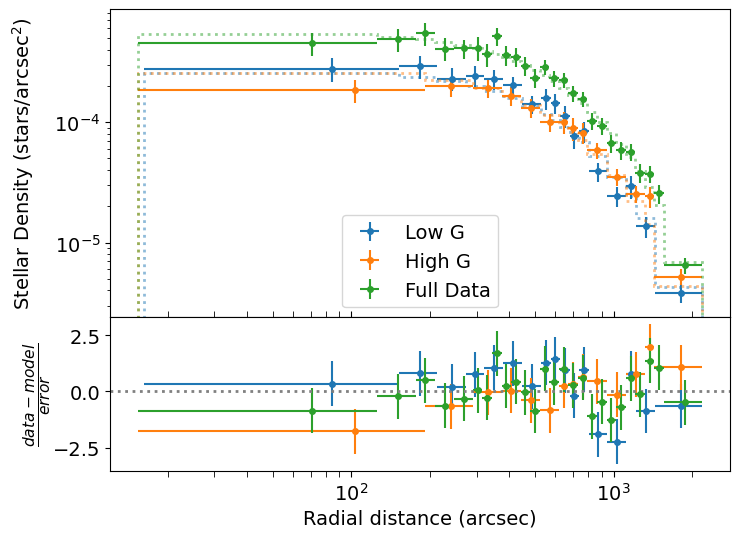

---------------------Fixed rc, rt parameters-------------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 69
    # data points      = 57
    # variables        = 5
    chi-square         = 46.4447995
    reduced chi-square = 0.89316922
    Akaike info crit   = -1.67284583
    Bayesian info crit = 8.54241051
[[Variables]]
    rho01:  4.4360e-04 +/- 2.5116e-05 (5.66%) (init = 0.01)
    c1:     0 (fixed)
    rc1:    601.677022 +/- 34.5749867 (5.75%) (init = 150)
    rt1:    2621.69080 +/- 93.5655841 (3.57%) (init = 2000)
    rho02:  4.5213e-04 +/- 2.4351e-05 (5.39%) (init = 0.01)
    c2:     0 (fixed)
    rc2:    601.677022 +/- 34.5749867 (5.75%) == 'rc1'
    rt2:    2621.69080 +/- 93.5655841 (3.57%) == 'rt1'
    rho03:  9.1241e-04 +/- 4.0608e-05 (4.45%) (init = 0.01)
    c3:     0 (fixed)
    rc3:    601.677022 +/- 34.5749867 (5.75%) == 'rc1'
    rt3:    2621.69080 +/- 93.5655841 (3.57%) == 'rt1'
[[Correlations]] (unreported correlations are < 0.1

In [12]:
cluster_data['Abs_PM'] = np.sqrt((cluster_data['pmRA'] )**2 + (cluster_data['pmDE'] )**2)

# Step 2: Define percentiles for subsamples
G_percentile = np.percentile(cluster_data['Gmag'], 50)  # Median split for G-band
PM_percentile = np.percentile(cluster_data['Abs_PM'], 50)  # Median split for proper motion

# Create subsamples 
G_low = cluster_data[cluster_data['Gmag'] <= G_percentile]
G_high = cluster_data[cluster_data['Gmag'] > G_percentile]
PM_low = cluster_data[cluster_data['Abs_PM'] <= PM_percentile]
PM_high = cluster_data[cluster_data['Abs_PM'] > PM_percentile]


density, edges2, bin_centers, yerr, xerr = cluster_hist(cluster_data)
density_lowG, edges2_lowG, bin_centers_lowG, yerr_lowG, xerr_lowG = cluster_hist(G_low)
density_highG, edges2_highG, bin_centers_highG, yerr_highG, xerr_highG = cluster_hist(G_high)
density_lowPM, edges2_lowPM, bin_centers_lowPM, yerr_lowPM, xerr_lowPM = cluster_hist(PM_low)
density_highPM, edges2_highPM, bin_centers_highPM, yerr_highPM, xerr_highPM = cluster_hist(PM_high)


output_resid = True

xdata=[]
ydata=[]
yerrs=[]

# Define data sets
datasets = [
    (edges2_lowG, density_lowG, yerr_lowG),
    (edges2_highG, density_highG, yerr_highG),
    (edges2, density, yerr)
]

xdata, ydata, yerrs = zip(*datasets)

# Convert tuples to lists
xdata, ydata, yerrs = list(xdata), list(ydata), list(yerrs)


#all fixed except rho0
params = Parameters()
params.add_many(('rho01',0.01, True, 0, 0.1),('c1',0,False, None, None),('rc1', 150,True,0,1000), ('rt1', 2000,True, 0,5000),
                #high gmag
                ('rho02',0.01, True, 0, 0.1),('c2',0,False, None, None),('rc2', 150, True, 0, 1000, 'rc1'), ('rt2', 2000, True, 0, 5000, 'rt1'),
                #full cluster
                ('rho03',0.01, True, 0, 0.1),('c3',0,False, None, None),('rc3', 150, True, 0, 1000, 'rc1'), ('rt3', 2000, True, 0, 5000, 'rt1'))

set_functionG1 = Minimizer(lmf_lsq_binresid_mult, params, fcn_args=(xdata, ydata, yerrs, King_profile_mult, output_resid),nan_policy='omit')
result_multG1 = set_functionG1.minimize(method = 'leastsq')

model_vals = lmf_lsq_binresid_mult(result_multG1.params,xdata,ydata,yerrs,King_profile_mult,output_resid=False)
legend_labels = ['Low Gmag', 'High Gmag', 'Full Population']
plot_spec_model_mult(xdata, ydata, yerrs, model_vals, 'weighted resid', legend_labels=['Low G', 'High G', 'Full Data'])

print("---------------------Fixed rc, rt parameters-------------------------")
print(fit_report(result_multG1))
print("Minimum Chi-squared = "+str(result_multG1.chisqr)+" for "+str(result_multG1.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result_multG1.chisqr,df=result_multG1.nfree))



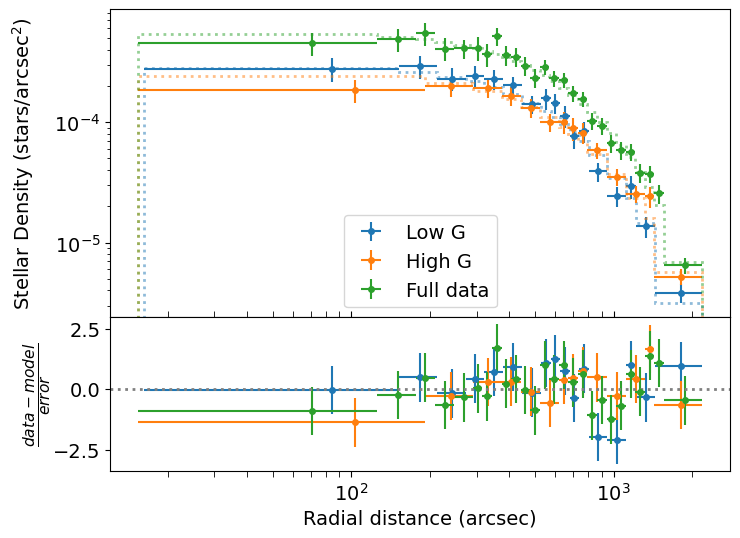

---------------------Fixed rc, and free rt--------------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 99
    # data points      = 57
    # variables        = 7
    chi-square         = 38.7404110
    reduced chi-square = 0.77480822
    Akaike info crit   = -8.01157604
    Bayesian info crit = 6.28978284
[[Variables]]
    rho01:  5.0997e-04 +/- 3.6845e-05 (7.22%) (init = 0.01)
    c1:     0 (fixed)
    rc1:    597.492598 +/- 31.9543276 (5.35%) (init = 150)
    rt1:    2391.24320 +/- 110.885010 (4.64%) (init = 2000)
    rho02:  3.9750e-04 +/- 2.9536e-05 (7.43%) (init = 0.01)
    c2:     0 (fixed)
    rc2:    597.492598 +/- 31.9543277 (5.35%) == 'rc1'
    rt2:    2945.00969 +/- 185.347477 (6.29%) (init = 2000)
    rho03:  9.1487e-04 +/- 4.5084e-05 (4.93%) (init = 0.01)
    c3:     0 (fixed)
    rc3:    597.492598 +/- 31.9543277 (5.35%) == 'rc1'
    rt3:    2625.11077 +/- 101.201583 (3.86%) (init = 2000)
[[Correlations]] (unreported correlations 

In [13]:
#Fixed rc, and free rt
params = Parameters()
params.add_many(('rho01',0.01, True, 0, 0.1),('c1',0,False, None, None),('rc1', 150,True,0,1000), ('rt1', 2000,True, 0,5000),
                #high gmag
                ('rho02',0.01, True, 0, 0.1),('c2',0,False, None, None),('rc2', 150, True, 0, 1000, 'rc1'), ('rt2', 2000, True, 0, 5000),
                #full cluster
                ('rho03',0.01, True, 0, 0.1),('c3',0,False, None, None),('rc3', 150, True, 0, 1000, 'rc1'), ('rt3', 2000, True, 0, 5000))

set_functionG2 = Minimizer(lmf_lsq_binresid_mult, params, fcn_args=(xdata, ydata, yerrs, King_profile_mult, output_resid),nan_policy='omit')
result_multG2 = set_functionG2.minimize(method = 'leastsq')

model_vals = lmf_lsq_binresid_mult(result_multG2.params,xdata,ydata,yerrs,King_profile_mult,output_resid=False)
plot_spec_model_mult(xdata, ydata, yerrs, model_vals, 'weighted resid', legend_labels = ['Low G', 'High G', 'Full data'])

print("---------------------Fixed rc, and free rt--------------------------")
print(fit_report(result_multG2))
print("Minimum Chi-squared = "+str(result_multG2.chisqr)+" for "+str(result_multG2.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result_multG2.chisqr,df=result_multG2.nfree))


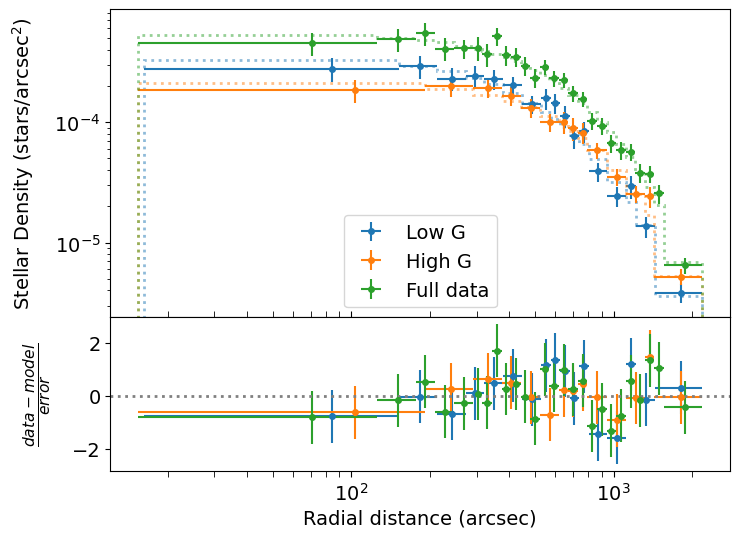

---------------------Fixed rt, and free rc--------------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 91
    # data points      = 57
    # variables        = 7
    chi-square         = 33.6159372
    reduced chi-square = 0.67231874
    Akaike info crit   = -16.0989066
    Bayesian info crit = -1.79754769
[[Variables]]
    rho01:  5.2091e-04 +/- 3.4067e-05 (6.54%) (init = 0.01)
    c1:     0 (fixed)
    rc1:    496.701195 +/- 35.6716934 (7.18%) (init = 150)
    rt1:    2607.12319 +/- 79.9187041 (3.07%) (init = 2000)
    rho02:  4.1493e-04 +/- 2.3286e-05 (5.61%) (init = 0.01)
    c2:     0 (fixed)
    rc2:    739.649158 +/- 58.9404882 (7.97%) (init = 150)
    rt2:    2607.12319 +/- 79.9187039 (3.07%) == 'rt1'
    rho03:  9.1174e-04 +/- 3.9541e-05 (4.34%) (init = 0.01)
    c3:     0 (fixed)
    rc3:    609.579828 +/- 36.5341247 (5.99%) (init = 150)
    rt3:    2607.12319 +/- 79.9187039 (3.07%) == 'rt1'
[[Correlations]] (unreported correlations a

In [14]:
#Fixed rt, and free rc
params = Parameters()
params.add_many(('rho01',0.01, True, 0, 0.1),('c1',0,False, None, None),('rc1', 150,True,0,1000), ('rt1', 2000,True, 0,5000),
                #high gmag
                ('rho02',0.01, True, 0, 0.1),('c2',0,False, None, None),('rc2', 150, True, 0, 1000), ('rt2', 2000, True, 0, 5000, 'rt1'),
                #full cluster
                ('rho03',0.01, True, 0, 0.1),('c3',0,False, None, None),('rc3', 150, True, 0, 1000), ('rt3', 2000, True, 0, 5000, 'rt1'))

set_functionG3 = Minimizer(lmf_lsq_binresid_mult, params, fcn_args=(xdata, ydata, yerrs, King_profile_mult, output_resid),nan_policy='omit')
result_multG3 = set_functionG3.minimize(method = 'leastsq')

model_vals = lmf_lsq_binresid_mult(result_multG3.params,xdata,ydata,yerrs,King_profile_mult,output_resid=False)
plot_spec_model_mult(xdata, ydata, yerrs, model_vals, 'weighted resid', legend_labels = ['Low G', 'High G', 'Full data'])

print("---------------------Fixed rt, and free rc--------------------------")
print(fit_report(result_multG3))
print("Minimum Chi-squared = "+str(result_multG3.chisqr)+" for "+str(result_multG3.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result_multG3.chisqr,df=result_multG3.nfree))


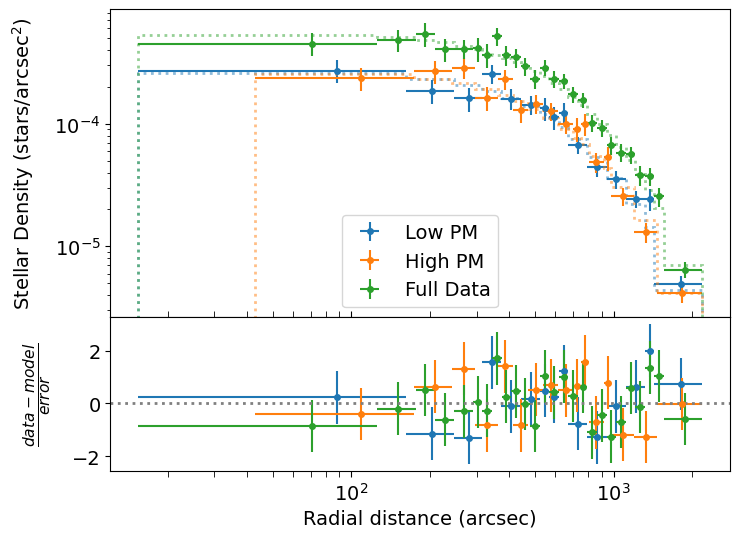

---------------------Fixed rc, rt parameters-------------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 69
    # data points      = 57
    # variables        = 5
    chi-square         = 43.6048387
    reduced chi-square = 0.83855459
    Akaike info crit   = -5.26933919
    Bayesian info crit = 4.94591715
[[Variables]]
    rho01:  4.4699e-04 +/- 2.3570e-05 (5.27%) (init = 0.01)
    c1:     0 (fixed)
    rc1:    600.200430 +/- 33.5276911 (5.59%) (init = 150)
    rt1:    2636.09822 +/- 92.3562141 (3.50%) (init = 2000)
    rho02:  4.4818e-04 +/- 2.4213e-05 (5.40%) (init = 0.01)
    c2:     0 (fixed)
    rc2:    600.200430 +/- 33.5276910 (5.59%) == 'rc1'
    rt2:    2636.09822 +/- 92.3562141 (3.50%) == 'rt1'
    rho03:  9.0728e-04 +/- 3.9201e-05 (4.32%) (init = 0.01)
    c3:     0 (fixed)
    rc3:    600.200430 +/- 33.5276910 (5.59%) == 'rc1'
    rt3:    2636.09822 +/- 92.3562141 (3.50%) == 'rt1'
[[Correlations]] (unreported correlations are < 0.1

In [15]:
output_resid = True

xdata=[]
ydata=[]
yerrs=[]

# Define data sets
datasets = [
    (edges2_lowPM, density_lowPM, yerr_lowPM),
    (edges2_highPM, density_highPM, yerr_highPM),
    (edges2, density, yerr)]

xdata, ydata, yerrs = zip(*datasets)

# Convert tuples to lists
xdata, ydata, yerrs = list(xdata), list(ydata), list(yerrs)


# Fixed rc, rt
params = Parameters()
params.add_many(('rho01',0.01, True, 0, 0.1),('c1',0,False, None, None),('rc1', 150,True,0,1000), ('rt1', 2000,True, 0,5000),
                #high gmag
                ('rho02',0.01, True, 0, 0.1),('c2',0,False, None, None),('rc2', 150, True, 0, 1000, 'rc1'), ('rt2', 2000, True, 0, 5000, 'rt1'),
                #full cluster
                ('rho03',0.01, True, 0, 0.1),('c3',0,False, None, None),('rc3', 150, True, 0, 1000, 'rc1'), ('rt3', 2000, True, 0, 5000, 'rt1'))

set_functionPM1 = Minimizer(lmf_lsq_binresid_mult, params, fcn_args=(xdata, ydata, yerrs, King_profile_mult, output_resid),nan_policy='omit')
result_multPM1 = set_functionPM1.minimize(method = 'leastsq')

model_vals = lmf_lsq_binresid_mult(result_multPM1.params,xdata,ydata,yerrs,King_profile_mult,output_resid=False)

plot_spec_model_mult(xdata, ydata, yerrs, model_vals, 'weighted resid', legend_labels=['Low PM', 'High PM', 'Full Data'])

print("---------------------Fixed rc, rt parameters-------------------------")
print(fit_report(result_multPM1))
print("Minimum Chi-squared = "+str(result_multPM1.chisqr)+" for "+str(result_multPM1.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result_multPM1.chisqr,df=result_multPM1.nfree))



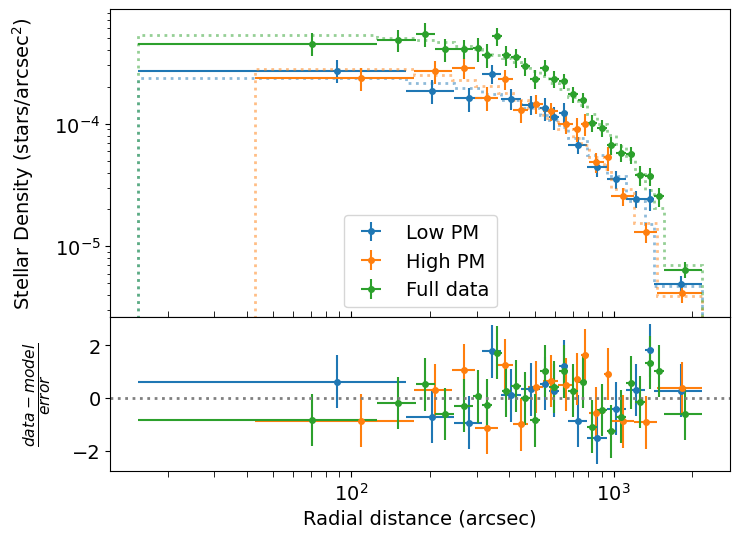

---------------------Fixed rt, and free rc--------------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 91
    # data points      = 57
    # variables        = 7
    chi-square         = 41.5208564
    reduced chi-square = 0.83041713
    Akaike info crit   = -4.06075799
    Bayesian info crit = 10.2406009
[[Variables]]
    rho01:  4.2600e-04 +/- 2.7628e-05 (6.49%) (init = 0.01)
    c1:     0 (fixed)
    rc1:    653.938104 +/- 56.5921234 (8.65%) (init = 150)
    rt1:    2634.73119 +/- 91.7430292 (3.48%) (init = 2000)
    rho02:  4.7384e-04 +/- 3.2906e-05 (6.94%) (init = 0.01)
    c2:     0 (fixed)
    rc2:    555.597571 +/- 45.8481750 (8.25%) (init = 150)
    rt2:    2634.73119 +/- 91.7430290 (3.48%) == 'rt1'
    rho03:  9.0629e-04 +/- 4.4001e-05 (4.86%) (init = 0.01)
    c3:     0 (fixed)
    rc3:    601.872119 +/- 40.0846852 (6.66%) (init = 150)
    rt3:    2634.73119 +/- 91.7430290 (3.48%) == 'rt1'
[[Correlations]] (unreported correlations ar

In [16]:
#Fixed rt, and free rc
params = Parameters()
params.add_many(('rho01',0.01, True, 0, 0.1),('c1',0,False, None, None),('rc1', 150,True,0,1000), ('rt1', 2000,True, 0,5000),
                #high gmag
                ('rho02',0.01, True, 0, 0.1),('c2',0,False, None, None),('rc2', 150, True, 0, 1000), ('rt2', 2000, True, 0, 5000, 'rt1'),
                #full cluster
                ('rho03',0.01, True, 0, 0.1),('c3',0,False, None, None),('rc3', 150, True, 0, 1000), ('rt3', 2000, True, 0, 5000, 'rt1'))

set_functionPM2 = Minimizer(lmf_lsq_binresid_mult, params, fcn_args=(xdata, ydata, yerrs, King_profile_mult, output_resid),nan_policy='omit')
result_multPM2 = set_functionPM2.minimize(method = 'leastsq')

model_vals = lmf_lsq_binresid_mult(result_multPM2.params,xdata,ydata,yerrs,King_profile_mult,output_resid=False)
plot_spec_model_mult(xdata, ydata, yerrs, model_vals, 'weighted resid', legend_labels = ['Low PM', 'High PM', 'Full data'])

print("---------------------Fixed rt, and free rc--------------------------")
print(fit_report(result_multPM2))
print("Minimum Chi-squared = "+str(result_multPM2.chisqr)+" for "+str(result_multPM2.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result_multPM2.chisqr,df=result_multPM2.nfree))


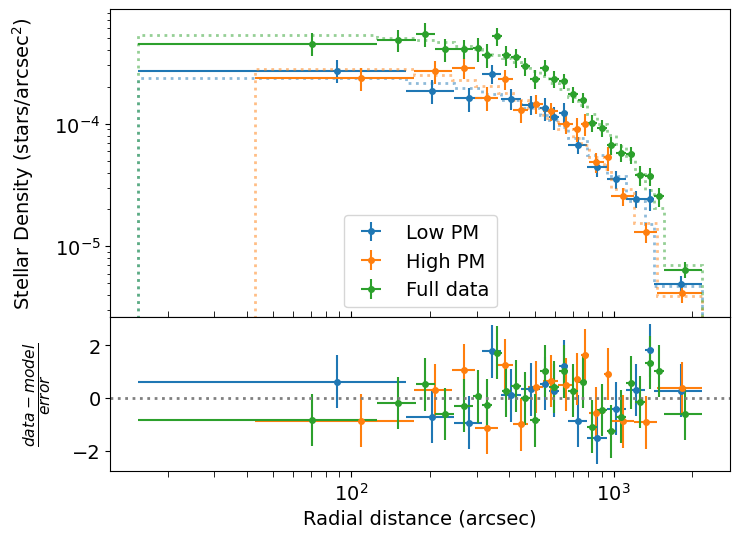

---------------------Fixed rt, and free rc--------------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 91
    # data points      = 57
    # variables        = 7
    chi-square         = 41.5208564
    reduced chi-square = 0.83041713
    Akaike info crit   = -4.06075799
    Bayesian info crit = 10.2406009
[[Variables]]
    rho01:  4.2600e-04 +/- 2.7628e-05 (6.49%) (init = 0.01)
    c1:     0 (fixed)
    rc1:    653.938104 +/- 56.5921234 (8.65%) (init = 150)
    rt1:    2634.73119 +/- 91.7430292 (3.48%) (init = 2000)
    rho02:  4.7384e-04 +/- 3.2906e-05 (6.94%) (init = 0.01)
    c2:     0 (fixed)
    rc2:    555.597571 +/- 45.8481750 (8.25%) (init = 150)
    rt2:    2634.73119 +/- 91.7430290 (3.48%) == 'rt1'
    rho03:  9.0629e-04 +/- 4.4001e-05 (4.86%) (init = 0.01)
    c3:     0 (fixed)
    rc3:    601.872119 +/- 40.0846852 (6.66%) (init = 150)
    rt3:    2634.73119 +/- 91.7430290 (3.48%) == 'rt1'
[[Correlations]] (unreported correlations ar

In [17]:
#Fixed rt, and free rc
params = Parameters()
params.add_many(('rho01',0.01, True, 0, 0.1),('c1',0,False, None, None),('rc1', 150,True,0,1000), ('rt1', 2000,True, 0,5000),
                #high gmag
                ('rho02',0.01, True, 0, 0.1),('c2',0,False, None, None),('rc2', 150, True, 0, 1000), ('rt2', 2000, True, 0, 5000, 'rt1'),
                #full cluster
                ('rho03',0.01, True, 0, 0.1),('c3',0,False, None, None),('rc3', 150, True, 0, 1000), ('rt3', 2000, True, 0, 5000, 'rt1'))

set_functionPM3 = Minimizer(lmf_lsq_binresid_mult, params, fcn_args=(xdata, ydata, yerrs, King_profile_mult, output_resid),nan_policy='omit')
result_multPM3 = set_functionPM3.minimize(method = 'leastsq')

model_vals = lmf_lsq_binresid_mult(result_multPM3.params,xdata,ydata,yerrs,King_profile_mult,output_resid=False)
plot_spec_model_mult(xdata, ydata, yerrs, model_vals, 'weighted resid', legend_labels = ['Low PM', 'High PM', 'Full data'])

print("---------------------Fixed rt, and free rc--------------------------")
print(fit_report(result_multPM3))
print("Minimum Chi-squared = "+str(result_multPM3.chisqr)+" for "+str(result_multPM3.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result_multPM3.chisqr,df=result_multPM3.nfree))
